<a href="https://colab.research.google.com/github/komaljakhal/-Web-development-project/blob/main/COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (57394, 49)
Rows: 57394, Columns: 49
iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million           

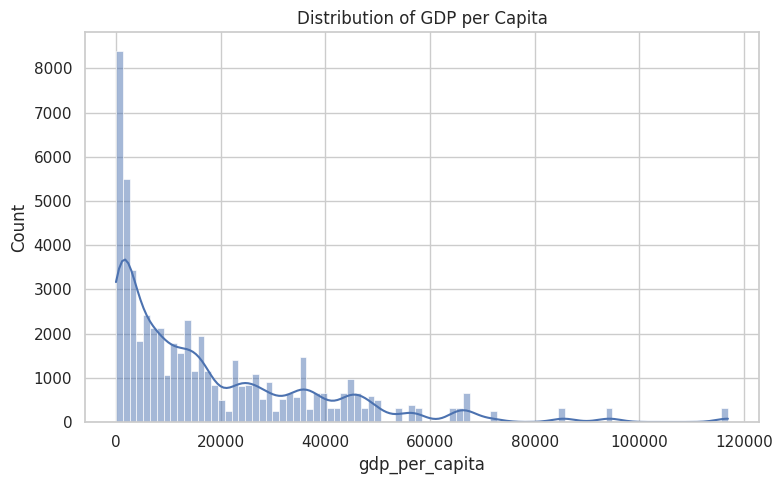

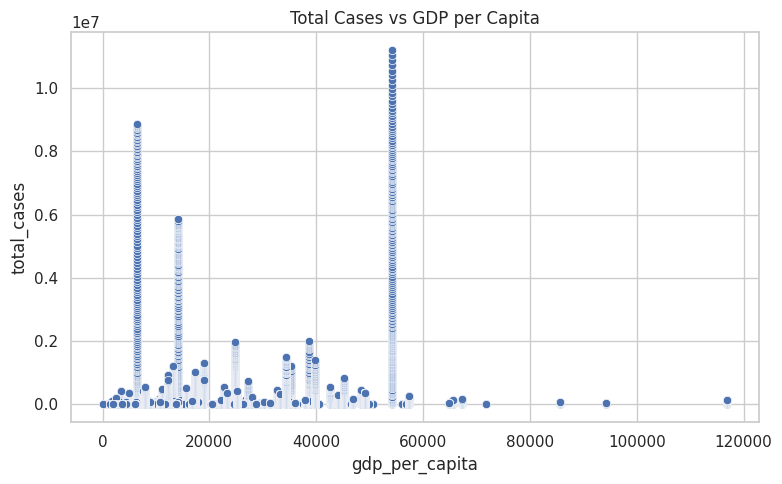

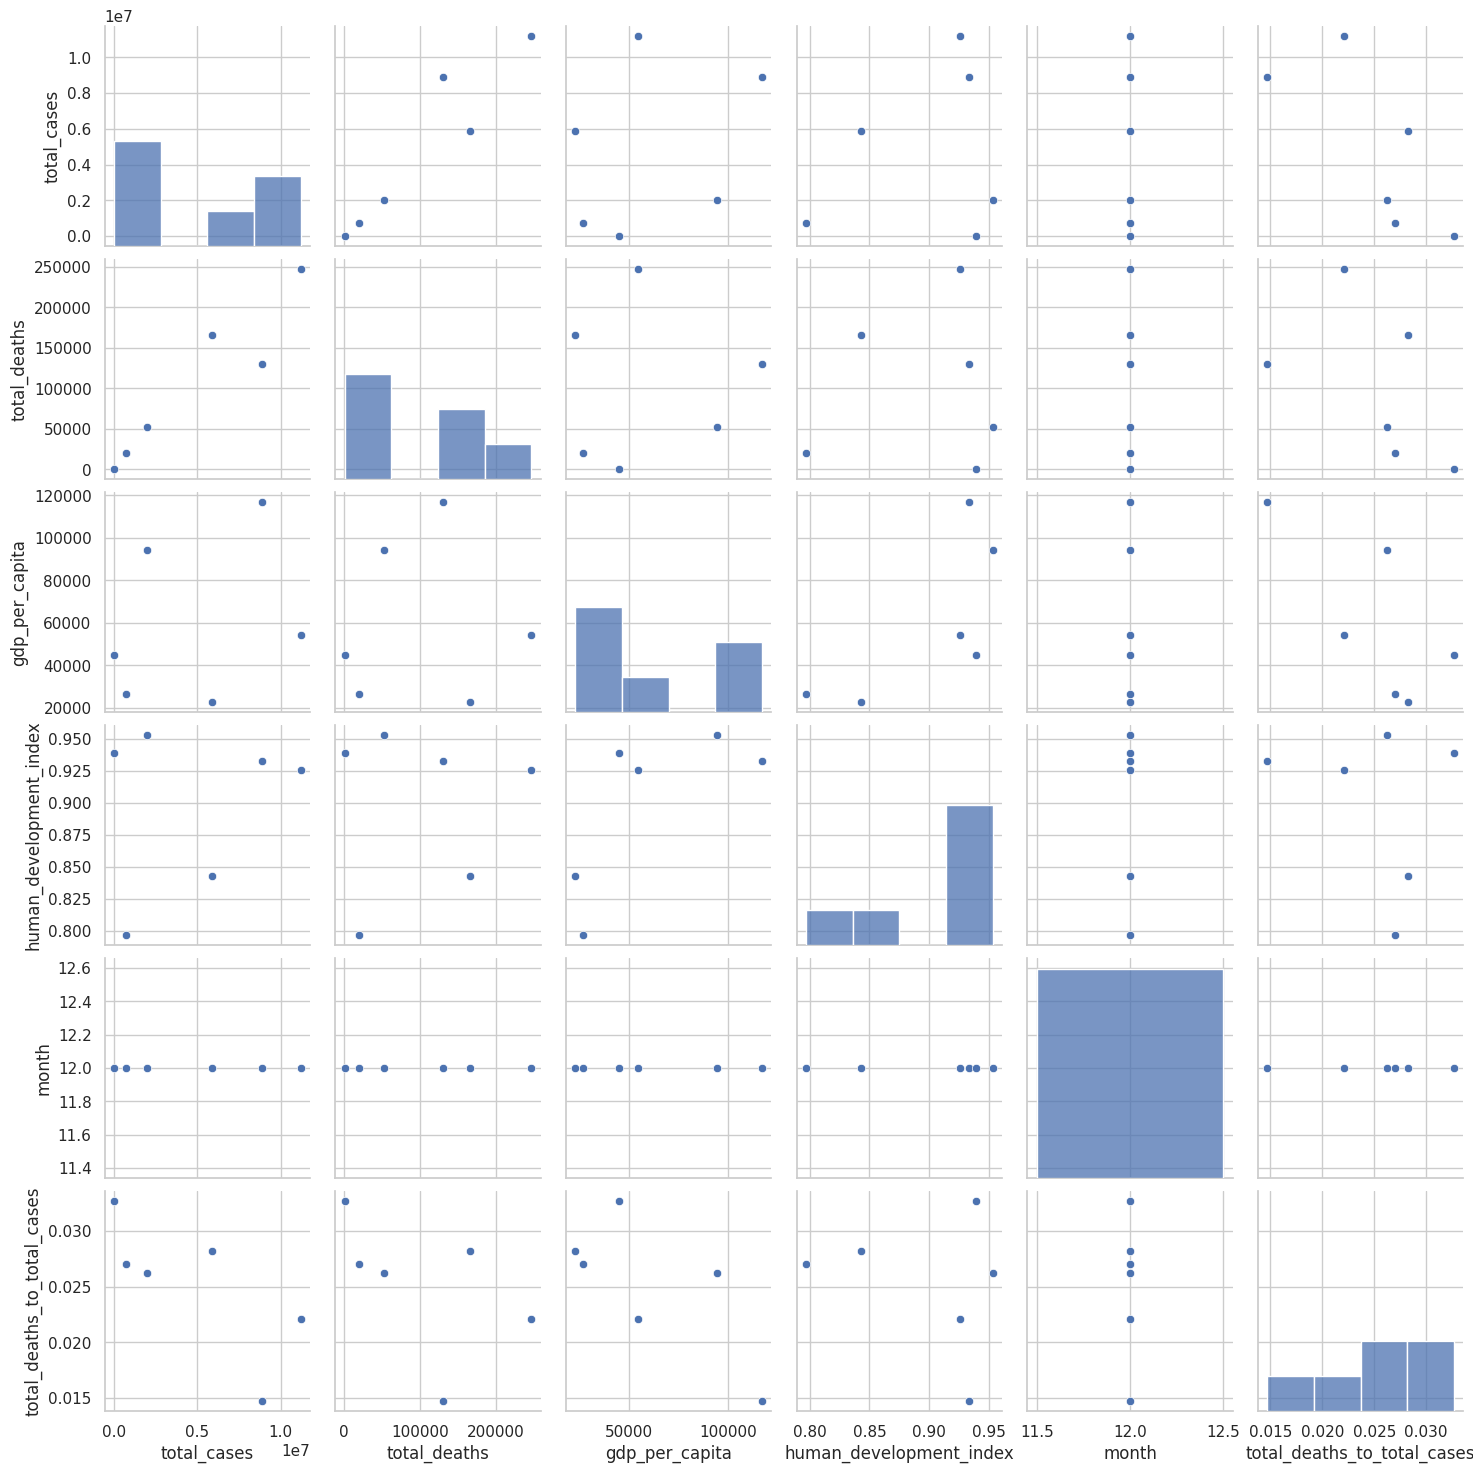

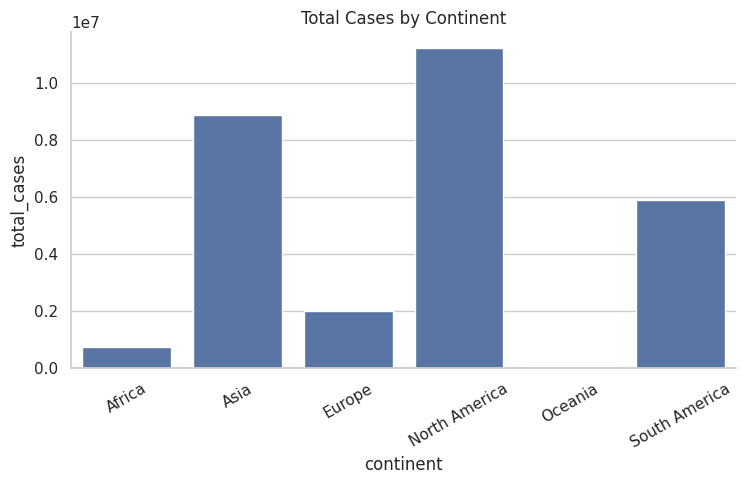

Saved df_groupby.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Import the dataset
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)

# 2. High Level Data Understanding
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")   # 2a
print(df.dtypes)                                          # 2b
df.info()                                                  # 2c
print(df.describe(include='all'))                          # 2c

# 3. Low Level Data Understanding
print(df['location'].nunique())                                    # 3a
print(df['continent'].value_counts())                              # 3b
print("Top continent:", df['continent'].value_counts().idxmax())
print("Max total_cases:", df['total_cases'].max())                 # 3c
print("Mean total_cases:", df['total_cases'].mean())
print(df['total_deaths'].quantile([0.25, 0.5, 0.75]))               # 3d
print(df.groupby('continent')['human_development_index'].max().idxmax())  # 3e
print(df.groupby('continent')['gdp_per_capita'].min().idxmin())            # 3f

# 4. Filter the dataframe to required columns
cols = ['continent', 'location', 'date', 'total_cases', 'total_deaths',
        'gdp_per_capita', 'human_development_index']
df = df[cols]

# 5. Data Cleaning
df = df.drop_duplicates()                        # 5a
print(df.isnull().sum())                          # 5b
df = df.dropna(subset=['continent'])              # 5c
df = df.fillna(0)                                 # 5d

# 6. Date time format
 # 6a
df['date'] = pd.to_datetime(df['date'], format='mixed')
# 6b
df['month'] = df['date'].dt.month

# 7. Data Aggregation
df_groupby = df.groupby('continent').max(numeric_only=False).reset_index()

# 8. Feature Engineering
df_groupby['total_deaths_to_total_cases'] = (
    df_groupby['total_deaths'] / df_groupby['total_cases']
)

# 9. Data Visualization
# 9a. Histogram of gdp_per_capita
plt.figure(figsize=(8, 5))
sns.histplot(df['gdp_per_capita'], kde=True)
plt.title("Distribution of GDP per Capita")
plt.tight_layout()
plt.show()

# 9b. Scatter plot: total_cases vs gdp_per_capita
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='gdp_per_capita', y='total_cases')
plt.title("Total Cases vs GDP per Capita")
plt.tight_layout()
plt.show()

# 9c. Pairplot on df_groupby
sns.pairplot(df_groupby)
plt.show()

# 9d. Bar plot: continent vs total_cases
g = sns.catplot(data=df_groupby, x='continent', y='total_cases', kind='bar', height=5, aspect=1.5)
g.set_xticklabels(rotation=30)
plt.title("Total Cases by Continent")
plt.tight_layout()
plt.show()

# 10. Save df_groupby to CSV
df_groupby.to_csv("df_groupby.csv", index=False)
print("Saved df_groupby.csv")